# 🏦 Bank Marketing Campaign Prediction
## Final Model Development & Deployment Pipeline

### Objective

Build a production-ready machine learning pipeline to predict whether a
customer will subscribe to a bank term deposit.

### Notebook 1 Findings

Random Forest was the strongest baseline model.

The `duration` feature was highly predictive, but it represents the duration
of the current call and is not available before the customer is contacted.

Therefore, this notebook focuses primarily on the **pre-call targeting use case**
and excludes `duration` from the production feature set.

### Workflow

1. Load data
2. Define target and features
3. Remove unavailable/leakage-prone feature (`duration`)
4. Train/validation split
5. Build preprocessing pipeline
6. Build baseline Random Forest
7. Hyperparameter tuning
8. Cross-validation
9. Threshold optimization
10. Final model selection
11. Final evaluation on untouched test data
12. Save complete pipeline
13. Prepare for deployment

In [ ]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-validation split and hyperparameter tuning
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Pipeline
from sklearn.pipeline import Pipeline

# Machine Learning model
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Model saving
import joblib

# To make results reproducible
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================
# PROJECT CONFIGURATION
# ============================================

# Target column
TARGET = "y"

# Random seed for reproducibility
RANDOM_STATE = 42

# Validation size
VALIDATION_SIZE = 0.20

# Number of CV folds
CV_FOLDS = 5

print("Configuration loaded.")

Configuration loaded.


In [ ]:
# ============================================
# LOAD TRAINING AND TEST DATA
# ============================================

# Update these paths according to your actual files
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

train = pd.read_csv(TRAIN_PATH, sep=";")
test = pd.read_csv(TEST_PATH, sep=";")

print("Training shape:", train.shape)
print("Test shape:", test.shape)

Training shape: (45211, 17)
Test shape: (4521, 17)


In [ ]:
# ============================================
# BASIC DATA VALIDATION
# ============================================

print("Training columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nTarget distribution:")
print(train[TARGET].value_counts())

print("\nTarget percentage:")
print(
    train[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Test columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentage:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


In [ ]:
# ============================================
# SEPARATE FEATURES AND TARGET
# ============================================

X = train.drop(columns=[TARGET])
y = train[TARGET].map({
    "no": 0,
    "yes": 1
})

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET].map({
    "no": 0,
    "yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X shape: (45211, 16)
y shape: (45211,)
X_test shape: (4521, 16)
y_test shape: (4521,)


In [ ]:
# ============================================
# REMOVE DURATION FOR PRE-CALL TARGETING
# ============================================

# `duration` represents the duration of the current call.
# It is not known before the call takes place.
#
# Since our production use case is:
# "Which customers should the bank contact?"
# we cannot depend on duration.

if "duration" in X.columns:
    X = X.drop(columns=["duration"])

if "duration" in X_test.columns:
    X_test = X_test.drop(columns=["duration"])

print("Duration removed.")
print("Final candidate feature count:", X.shape[1])

Duration removed.
Final candidate feature count: 15


In [ ]:
# ============================================
# TRAIN / VALIDATION SPLIT
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

Training: (36168, 15)
Validation: (9043, 15)

Training target distribution:
y
0    0.883018
1    0.116982
Name: proportion, dtype: float64

Validation target distribution:
y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


In [ ]:
# ============================================
# IDENTIFY FEATURE TYPES
# ============================================

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [ ]:
# ============================================
# PREPROCESSING PIPELINE
# ============================================

# Numerical variables do not require scaling for Random Forest.
# Therefore, they are passed through unchanged.

numeric_transformer = "passthrough"

# Categorical variables are converted into binary columns
# using One-Hot Encoding.
#
# handle_unknown="ignore" prevents errors if the validation/test
# set contains a category not observed during training.

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [ ]:
# ============================================
# BASELINE RANDOM FOREST PIPELINE
# ============================================

baseline_pipeline = Pipeline([
    
    # Step 1:
    # Transform raw features into model-ready features
    (
        "preprocessor",
        preprocessor
    ),
    
    # Step 2:
    # Train Random Forest
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_split=10,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

print("Baseline pipeline created.")

Baseline pipeline created.


In [ ]:
# ============================================
# TRAIN BASELINE MODEL
# ============================================

baseline_pipeline.fit(
    X_train,
    y_train
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [ ]:
# ============================================
# MODEL EVALUATION FUNCTION
# ============================================

def evaluate_classifier(model, X_data, y_data, threshold=0.50):
    """
    Evaluate a classification model.

    threshold:
        Probability threshold used to convert predicted
        probabilities into 0/1 predictions.
    """

    # Get probability of positive class
    probabilities = model.predict_proba(X_data)[:, 1]

    # Convert probability into class prediction
    predictions = (
        probabilities >= threshold
    ).astype(int)

    results = {
        "Accuracy": accuracy_score(y_data, predictions),
        "Precision": precision_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_data,
            probabilities
        )
    }

    return results

In [ ]:
# ============================================
# BASELINE EVALUATION
# ============================================

baseline_results = evaluate_classifier(
    baseline_pipeline,
    X_val,
    y_val
)

pd.DataFrame(
    [baseline_results],
    index=["Baseline Random Forest"]
)

,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline Random Forest,0.833684,0.367577,0.585066,0.451495,0.798571


In [ ]:
# ============================================
# STRATIFIED CROSS-VALIDATION
# ============================================

cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f"{CV_FOLDS}-Fold Stratified Cross-Validation configured.")

5-Fold Stratified Cross-Validation configured.


In [ ]:
# ============================================
# RANDOM FOREST HYPERPARAMETER SEARCH SPACE
# ============================================

param_distributions = {
    
    # Number of trees
    "model__n_estimators": [
        200,
        300,
        500,
        700
    ],
    
    # Maximum depth of each tree
    "model__max_depth": [
        8,
        10,
        12,
        15,
        20,
        None
    ],
    
    # Minimum samples required to split a node
    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],
    
    # Minimum samples required at a leaf
    "model__min_samples_leaf": [
        1,
        2,
        5,
        10
    ],
    
    # Number of features considered at each split
    "model__max_features": [
        "sqrt",
        "log2",
        None
    ],
    
    # Class weighting
    "model__class_weight": [
        "balanced",
        "balanced_subsample"
    ]
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


In [ ]:
# ============================================
# RANDOMIZED HYPERPARAMETER SEARCH
# ============================================

random_search = RandomizedSearchCV(
    
    # The complete pipeline is tuned.
    # This means preprocessing + model are treated as one unit.
    estimator=baseline_pipeline,
    
    # Hyperparameter combinations to sample
    param_distributions=param_distributions,
    
    # Number of random combinations
    n_iter=30,
    
    # Optimize F1 because the positive class is important
    # and the dataset is imbalanced.
    scoring="f1",
    
    # Stratified cross-validation
    cv=cv_strategy,
    
    # Reproducibility
    random_state=RANDOM_STATE,
    
    # Use all available CPU cores
    n_jobs=-1,
    
    # Show progress
    verbose=1
)

print("RandomizedSearchCV configured.")

RandomizedSearchCV configured.


In [ ]:
# ============================================
# RUN HYPERPARAMETER TUNING
# ============================================

import os
import joblib

SEARCH_FILE = "random_search_results.joblib"

if os.path.exists(SEARCH_FILE):
    
    # Load previously completed tuning
    random_search = joblib.load(SEARCH_FILE)
    
    print("Existing tuning results loaded.")
    print("Best CV F1:", random_search.best_score_)
    
else:
    
    # Run tuning only if results don't already exist
    print("No saved tuning results found.")
    print("Starting hyperparameter tuning...")
    
    random_search.fit(
        X_train,
        y_train
    )
    
    # Save results for future notebook restarts
    joblib.dump(
        random_search,
        SEARCH_FILE
    )
    
    print("Hyperparameter tuning completed and saved.")

Existing tuning results loaded.
Best CV F1: 0.46937874907914906


In [ ]:
# ============================================
# BEST HYPERPARAMETERS
# ============================================

print("Best Parameters:\n")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest Cross-Validation F1:")
print(random_search.best_score_)

Best Parameters:

model__n_estimators: 700
model__min_samples_split: 20
model__min_samples_leaf: 10
model__max_features: None
model__max_depth: None
model__class_weight: balanced

Best Cross-Validation F1:
0.46937874907914906


In [ ]:
# ============================================
# EXTRACT BEST MODEL
# ============================================

tuned_model = random_search.best_estimator_

print("Best tuned pipeline obtained.")

Best tuned pipeline obtained.


In [ ]:
# ============================================
# BASELINE VS TUNED MODEL
# ============================================

tuned_results = evaluate_classifier(
    tuned_model,
    X_val,
    y_val
)

comparison = pd.DataFrame(
    [
        baseline_results,
        tuned_results
    ],
    index=[
        "Baseline Random Forest",
        "Tuned Random Forest"
    ]
)

comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline Random Forest,0.833684,0.367577,0.585066,0.451495,0.798571
Tuned Random Forest,0.867190,0.444097,0.536862,0.486093,0.796065


In [ ]:
# Get probability of class 1 ("yes")
val_probabilities = tuned_model.predict_proba(X_val)[:, 1]

print("Minimum probability:", val_probabilities.min())
print("Maximum probability:", val_probabilities.max())

Minimum probability: 0.0036893597887642632
Maximum probability: 0.9832817482409067


In [ ]:
# ============================================
# THRESHOLD OPTIMIZATION
# ============================================

# Get validation probabilities
val_probabilities = tuned_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.30, 0.71, 0.01)

results = []

for threshold in thresholds:
    predictions = (val_probabilities >= threshold).astype(int)

    results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_val, predictions, zero_division=0),
        "Recall": recall_score(y_val, predictions, zero_division=0),
        "F1": f1_score(y_val, predictions, zero_division=0),
        "Accuracy": accuracy_score(y_val, predictions)
    })

threshold_df = pd.DataFrame(results)

# Show the best 10 thresholds based on F1
threshold_df.sort_values("F1", ascending=False).head(10)

,Threshold,Precision,Recall,F1,Accuracy
29,0.59,0.499031,0.486767,0.492823,0.882782
30,0.60,0.505988,0.479206,0.492233,0.884330
31,0.61,0.511202,0.474480,0.492157,0.885436
27,0.57,0.486586,0.497164,0.491819,0.879797
28,0.58,0.491958,0.491493,0.491726,0.881124
26,0.56,0.477948,0.501890,0.489627,0.877585
21,0.51,0.451484,0.532136,0.488503,0.869623
20,0.50,0.444097,0.536862,0.486093,0.867190
25,0.55,0.469190,0.503781,0.485871,0.875263
22,0.52,0.451012,0.526465,0.485826,0.869623


In [ ]:
# ============================================
# SELECT BEST THRESHOLD
# ============================================

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = float(best_row["Threshold"])

print("Best Threshold :", best_threshold)
print("Precision      :", round(best_row["Precision"], 4))
print("Recall         :", round(best_row["Recall"], 4))
print("F1 Score       :", round(best_row["F1"], 4))
print("Accuracy       :", round(best_row["Accuracy"], 4))

Best Threshold : 0.59
Precision      : 0.499
Recall         : 0.4868
F1 Score       : 0.4928
Accuracy       : 0.8828


In [ ]:
# ============================================
# FINAL VALIDATION EVALUATION
# ============================================

# Apply selected threshold
final_val_predictions = (
    val_probabilities >= best_threshold
).astype(int)

print("Selected Threshold:", best_threshold)
print("\nClassification Report:\n")

print(
    classification_report(
        y_val,
        final_val_predictions,
        target_names=["No", "Yes"]
    )
)

print("\nConfusion Matrix:\n")

cm = confusion_matrix(
    y_val,
    final_val_predictions
)

print(cm)

Selected Threshold: 0.59

Classification Report:

              precision    recall  f1-score   support

          No       0.93      0.94      0.93      7985
         Yes       0.50      0.49      0.49      1058

    accuracy                           0.88      9043
   macro avg       0.72      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043


Confusion Matrix:

[[7468  517]
 [ 543  515]]


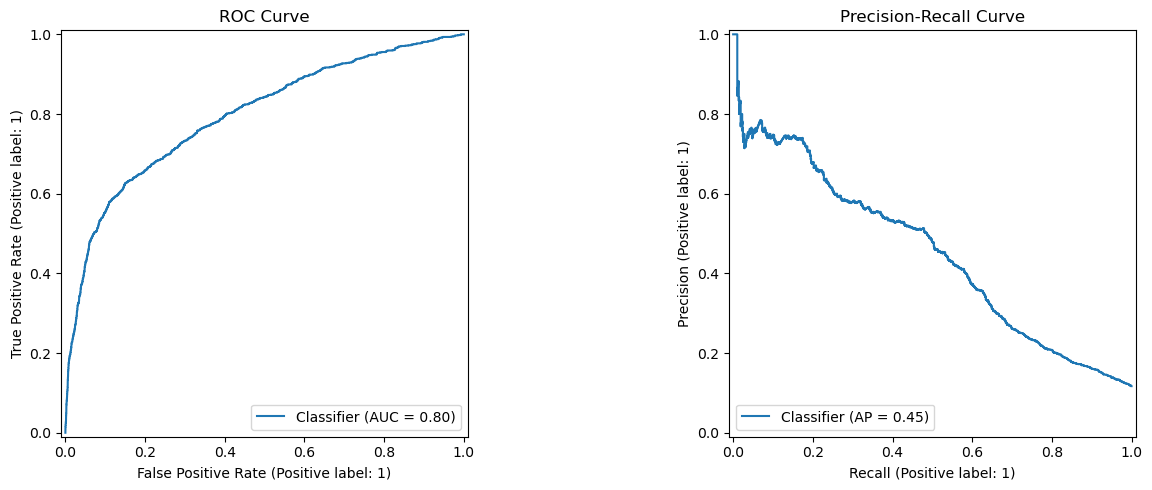

In [ ]:
# ============================================
# ROC & PRECISION-RECALL CURVES
# ============================================

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(
    y_val,
    val_probabilities,
    ax=axes[0]
)
axes[0].set_title("ROC Curve")

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_val,
    val_probabilities,
    ax=axes[1]
)
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# TRAIN FINAL MODEL ON COMPLETE TRAINING DATA
# ============================================

final_model = tuned_model

final_model.fit(
    X,
    y
)

print("Final model trained on complete training dataset.")

Final model trained on complete training dataset.


In [ ]:
# ============================================
# FINAL EVALUATION ON UNTOUCHED TEST DATA
# ============================================

# Get probability predictions
test_probabilities = final_model.predict_proba(X_test)[:, 1]

# Apply selected threshold
test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

# Calculate metrics
final_test_results = {
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Precision": precision_score(
        y_test, test_predictions, zero_division=0
    ),
    "Recall": recall_score(
        y_test, test_predictions, zero_division=0
    ),
    "F1": f1_score(
        y_test, test_predictions, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test, test_probabilities
    )
}

pd.DataFrame(
    [final_test_results],
    index=["Final Test Model"]
)

,Accuracy,Precision,Recall,F1,ROC-AUC
Final Test Model,0.903561,0.57885,0.598848,0.588679,0.955895


In [ ]:
# ============================================
# FINAL TEST CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    test_predictions
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix:
[[3773  227]
 [ 209  312]]

True Negatives : 3773
False Positives: 227
False Negatives: 209
True Positives : 312


In [ ]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

# Get trained Random Forest from the pipeline
rf_model = final_model.named_steps["model"]

# Get transformed feature names
feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Create feature importance dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
importance_df.head(15)

,Feature,Importance
1,num__balance,0.179993
48,cat__poutcome_success,0.130153
2,num__day,0.123366
0,num__age,0.111912
33,cat__contact_unknown,0.075002
3,num__campaign,0.053457
4,num__pdays,0.040244
27,cat__housing_no,0.034342
39,cat__month_jul,0.022845
35,cat__month_aug,0.021396


In [ ]:
# ============================================
# SAVE FINAL DEPLOYMENT ARTIFACTS
# ============================================

import os
import joblib

os.makedirs("models", exist_ok=True)

# Save complete preprocessing + model pipeline
joblib.dump(
    final_model,
    "models/bank_marketing_pipeline.joblib"
)

# Save classification threshold
joblib.dump(
    {"threshold": best_threshold},
    "models/deployment_config.joblib"
)

print("Deployment artifacts saved successfully.")
print("Model: models/bank_marketing_pipeline.joblib")
print("Threshold:", best_threshold)

Deployment artifacts saved successfully.
Model: models/bank_marketing_pipeline.joblib
Threshold: 0.59
